# Dataset Audit Notebook

Phase 1 only: dataset discovery, metadata inspection, label investigation, speaker investigation, quality assessment, and summary reporting. No preprocessing, no detection, no feature extraction, and no model code are included.

## 1. Dataset Discovery

This section scans the dataset recursively, counts files, identifies formats, and summarizes the folder structure.

In [25]:
%pip install opencv-python matplotlib pandas

from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import json
import sqlite3

import cv2
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

DATASET_ROOT = Path(r"C:\Users\prash\Downloads\archive (3)\data\s1")
OUTPUT_DIR = Path.cwd().parent / 'results' / 'phase1'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset root: {DATASET_ROOT}")
print(f"Exists: {DATASET_ROOT.exists()}")
print(f"Output directory: {OUTPUT_DIR}")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Dataset root: C:\Users\prash\Downloads\archive (3)\data\s1
Exists: True
Output directory: c:\Users\prash\Open-source\MANIT_INTERSHIP_PROJECT\Astronaut_Visual_Speech_Recognition\results\phase1



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
def scan_dataset(root: Path):
    all_files = [path for path in root.rglob('*') if path.is_file()]
    video_files = sorted(path for path in all_files if path.suffix.lower() in {'.mpg', '.mp4', '.avi', '.mov', '.mkv'})
    metadata_files = sorted(path for path in all_files if path.suffix.lower() in {'.csv', '.txt', '.json', '.md', '.db'})
    readme_files = sorted(path for path in all_files if 'readme' in path.name.lower())
    return all_files, video_files, metadata_files, readme_files

all_files, video_files, metadata_files, readme_files = scan_dataset(DATASET_ROOT)
file_extensions = Counter(path.suffix.lower() or '[no extension]' for path in all_files)
folder_summary = Counter(str(path.parent.relative_to(DATASET_ROOT)) if path.parent != DATASET_ROOT else '.' for path in all_files)

print(f'Total files: {len(all_files)}')
print(f'Total video files: {len(video_files)}')
print('File type distribution:')
print(file_extensions)
print('Folder structure summary:')
print(folder_summary)
print('Metadata files detected:')
print([path.name for path in metadata_files])

Total files: 1001
Total video files: 1000
File type distribution:
Counter({'.mpg': 1000, '.db': 1})
Folder structure summary:
Counter({'.': 1001})
Metadata files detected:
['Thumbs.db']


## 2. Video Metadata Extraction

This section extracts technical metadata for every video and exports the results to CSV.

In [3]:
def inspect_video(video_path: Path):
    record = {
        'Filename': video_path.name,
        'Extension': video_path.suffix.lower(),
        'Path': str(video_path),
        'File Size': video_path.stat().st_size,
        'Width': None,
        'Height': None,
        'Resolution': None,
        'FPS': None,
        'Duration': None,
        'Frame Count': None,
        'Readable': False,
        'Corrupted': False,
    }
    try:
        capture = cv2.VideoCapture(str(video_path))
        if not capture.isOpened():
            record['Corrupted'] = True
            return record

        fps = capture.get(cv2.CAP_PROP_FPS)
        frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
        width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
        duration = frame_count / fps if fps else None

        record.update({
            'Width': width,
            'Height': height,
            'Resolution': f'{width} x {height}',
            'FPS': fps,
            'Duration': duration,
            'Frame Count': frame_count,
            'Readable': True,
        })
        capture.release()
    except Exception as exc:
        record['Corrupted'] = True
        record['Error'] = str(exc)
    return record

video_records = [inspect_video(path) for path in video_files]
video_metadata_df = pd.DataFrame(video_records)
video_metadata_df.to_csv(OUTPUT_DIR / 'video_metadata.csv', index=False)

display(video_metadata_df.head())
display(video_metadata_df.describe(include='all').transpose())

,Filename,Extension,Path,File Size,Width,Height,Resolution,FPS,Duration,Frame Count,Readable,Corrupted
0,bbaf2n.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,452608,360,288,360 x 288,25.0,3.0,75,True,False
1,bbaf3s.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,438272,360,288,360 x 288,25.0,3.0,75,True,False
2,bbaf4p.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,430080,360,288,360 x 288,25.0,3.0,75,True,False
3,bbaf5a.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,446464,360,288,360 x 288,25.0,3.0,75,True,False
4,bbal6n.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,428032,360,288,360 x 288,25.0,3.0,75,True,False


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Filename,1000,1000,bbaf2n.mpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extension,1000,1,.mpg,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Path,1000,1000,C:\Users\prash\Downloads\archive (3)\data\s1\b...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
File Size,1000.0,NaN,NaN,NaN,431351.808,19006.884413,399360.0,417792.0,428032.0,438272.0,489472.0
Width,1000.0,NaN,NaN,NaN,360.0,0.0,360.0,360.0,360.0,360.0,360.0
Height,1000.0,NaN,NaN,NaN,288.0,0.0,288.0,288.0,288.0,288.0,288.0
Resolution,1000,1,360 x 288,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FPS,1000.0,NaN,NaN,NaN,25.0,0.0,25.0,25.0,25.0,25.0,25.0
Duration,1000.0,NaN,NaN,NaN,2.9998,0.002823,2.96,3.0,3.0,3.0,3.0
Frame Count,1000.0,NaN,NaN,NaN,74.995,0.070569,74.0,75.0,75.0,75.0,75.0


## 3. Label Investigation

This section searches filenames, folders, and metadata files for any verified label source. Labels are only reported when they can be directly supported by evidence.

In [4]:
def read_text_preview(path: Path, limit: int = 200):
    try:
        return path.read_text(encoding='utf-8', errors='ignore')[:limit]
    except Exception:
        return ''

def inspect_sqlite(path: Path):
    try:
        connection = sqlite3.connect(path)
        cursor = connection.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type IN ('table', 'view') ORDER BY name")
        tables = [row[0] for row in cursor.fetchall()]
        connection.close()
        return tables
    except Exception:
        return []

label_sources = []
for path in metadata_files:
    lower_name = path.name.lower()
    if lower_name.endswith('.csv'):
        try:
            label_sources.append({'path': str(path), 'type': 'csv', 'header': list(pd.read_csv(path, nrows=0).columns)})
        except Exception:
            label_sources.append({'path': str(path), 'type': 'csv', 'header': None})
    elif lower_name.endswith('.txt') or lower_name.endswith('.md'):
        label_sources.append({'path': str(path), 'type': path.suffix.lower().lstrip('.'), 'preview': read_text_preview(path)})
    elif lower_name.endswith('.db'):
        tables = inspect_sqlite(path)
        if tables:
            label_sources.append({'path': str(path), 'type': 'sqlite_db', 'tables': tables})

possible_label_columns = []
for source in label_sources:
    header = source.get('header')
    if header:
        candidates = [column for column in header if any(token in column.lower() for token in ['label', 'class', 'word', 'phrase', 'transcript', 'speaker'])]
        if candidates:
            possible_label_columns.append({'path': source['path'], 'candidates': candidates})

print('Label sources found:')
print(label_sources if label_sources else 'NO VERIFIED LABEL SOURCE FOUND')
print('Possible label columns:')
print(possible_label_columns if possible_label_columns else 'NO VERIFIED LABEL SOURCE FOUND')

labels_summary_df = pd.DataFrame(columns=['Label', 'Sample Count'])

Label sources found:
NO VERIFIED LABEL SOURCE FOUND
Possible label columns:
NO VERIFIED LABEL SOURCE FOUND


## 3.5. Alignment File Analysis

This section treats `.align` files as the authoritative transcript source and attaches transcripts to the existing video metadata dataframe.

In [23]:
def parse_align_file(align_path: Path):
    silence_tokens = {'sil', 'sp', 'silence'}
    transcript_tokens = []
    try:
        for raw_line in align_path.read_text(encoding='utf-8', errors='ignore').splitlines():
            line = raw_line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            token = parts[2].strip()
            if token.lower() in silence_tokens:
                continue
            transcript_tokens.append(token)
    except Exception as exc:
        return {'path': str(align_path), 'error': str(exc), 'tokens': [], 'transcript': '', 'word_count': 0}
    return {
        'path': str(align_path),
        'error': None,
        'tokens': transcript_tokens,
        'transcript': ' '.join(transcript_tokens),
        'word_count': len(transcript_tokens),
    }

ALIGNMENT_ROOT = Path(r"C:\Users\prash\Downloads\archive (3)\data\alignments\s1")
align_files = sorted(ALIGNMENT_ROOT.rglob('*.align'))
print(f'Alignment root: {ALIGNMENT_ROOT}')
print(f'Align files found: {len(align_files)}')
video_by_stem = {path.stem: path for path in video_files}
align_by_stem = {path.stem: path for path in align_files}

paired_stems = sorted(set(video_by_stem) & set(align_by_stem))
missing_video_for_align = sorted(set(align_by_stem) - set(video_by_stem))
missing_align_for_video = sorted(set(video_by_stem) - set(align_by_stem))

alignment_rows = []
all_transcript_tokens = []
for stem in paired_stems:
    align_info = parse_align_file(align_by_stem[stem])
    all_transcript_tokens.extend(align_info['tokens'])
    alignment_rows.append({
        'Filename': video_by_stem[stem].name,
        'Align_File': align_by_stem[stem].name,
        'Transcript': align_info['transcript'],
        'Word_Count': align_info['word_count'],
        'Parse_Error': align_info['error'],
    })

alignment_df = pd.DataFrame(alignment_rows)

transcript_columns = [column for column in video_metadata_df.columns if column.startswith('Transcript')]
if transcript_columns:
    video_metadata_df = video_metadata_df.drop(columns=transcript_columns)
if not alignment_df.empty:
    video_metadata_df = video_metadata_df.merge(alignment_df[['Filename', 'Transcript']], on='Filename', how='left')
else:
    video_metadata_df['Transcript'] = pd.NA

video_metadata_df.to_csv(OUTPUT_DIR / 'video_metadata.csv', index=False)

transcript_summary_df = alignment_df[['Filename', 'Transcript', 'Word_Count']].copy() if not alignment_df.empty else pd.DataFrame(columns=['Filename', 'Transcript', 'Word_Count'])
transcript_summary_df.to_csv(OUTPUT_DIR / 'transcript_summary.csv', index=False)

vocabulary_df = pd.DataFrame(Counter(all_transcript_tokens).items(), columns=['Word', 'Frequency']).sort_values('Frequency', ascending=False) if all_transcript_tokens else pd.DataFrame(columns=['Word', 'Frequency'])
vocabulary_df.to_csv(OUTPUT_DIR / 'vocabulary.csv', index=False)

pairing_validation_report = {
    'align_files_found': len(align_files),
    'video_align_pairs': len(paired_stems),
    'missing_video_for_align': missing_video_for_align,
    'missing_align_for_video': missing_align_for_video,
    'successful_pairs': len(paired_stems),
}

total_transcripts = len(alignment_df)
average_words_per_transcript = float(transcript_summary_df['Word_Count'].mean()) if not transcript_summary_df.empty else 0.0
minimum_words_per_transcript = int(transcript_summary_df['Word_Count'].min()) if not transcript_summary_df.empty else 0
maximum_words_per_transcript = int(transcript_summary_df['Word_Count'].max()) if not transcript_summary_df.empty else 0
vocabulary_size = int(vocabulary_df.shape[0])

print('Alignment file analysis:')
print(pairing_validation_report)
print(f'Total transcripts: {total_transcripts}')
print(f'Average words per transcript: {average_words_per_transcript:.3f}')
print(f'Minimum words per transcript: {minimum_words_per_transcript}')
print(f'Maximum words per transcript: {maximum_words_per_transcript}')
print(f'Vocabulary size: {vocabulary_size}')
display(transcript_summary_df.head())
display(vocabulary_df.head(20))
display(video_metadata_df.head())

if missing_video_for_align or missing_align_for_video:
    print('Pairing validation warnings detected.')
else:
    print('All videos and align files are successfully paired.')

Alignment root: C:\Users\prash\Downloads\archive (3)\data\alignments\s1
Align files found: 1000
Alignment file analysis:
{'align_files_found': 1000, 'video_align_pairs': 1000, 'missing_video_for_align': [], 'missing_align_for_video': [], 'successful_pairs': 1000}
Total transcripts: 1000
Average words per transcript: 6.000
Minimum words per transcript: 6
Maximum words per transcript: 6
Vocabulary size: 51


,Filename,Transcript,Word_Count
0,bbaf2n.mpg,bin blue at f two now,6
1,bbaf3s.mpg,bin blue at f three soon,6
2,bbaf4p.mpg,bin blue at f four please,6
3,bbaf5a.mpg,bin blue at f five again,6
4,bbal6n.mpg,bin blue at l six now,6


,Word,Frequency
46,place,256
50,set,256
2,at,252
23,in,252
9,please,250
11,again,250
37,red,250
29,green,250
7,soon,250
1,blue,250


,Filename,Extension,Path,File Size,Width,Height,Resolution,FPS,Duration,Frame Count,Readable,Corrupted,Transcript
0,bbaf2n.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,452608,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at f two now
1,bbaf3s.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,438272,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at f three soon
2,bbaf4p.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,430080,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at f four please
3,bbaf5a.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,446464,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at f five again
4,bbal6n.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,428032,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at l six now


All videos and align files are successfully paired.


## 4. Speaker Investigation

This section checks whether speaker identities are explicitly documented or can be verified from metadata. If not, the notebook states that no verified speaker information was found.

In [6]:
def infer_speaker_token(filename: str):
    stem = Path(filename).stem
    return stem[:4] if len(stem) >= 4 else stem

speaker_summary_df = pd.DataFrame(columns=['Speaker', 'Sample Count'])
speaker_sources = []
verified_speakers = False

for source in label_sources:
    tables = source.get('tables')
    header = source.get('header')
    preview = source.get('preview', '')
    if tables or header or preview:
        speaker_sources.append(source)

print('Speaker sources found:')
print(speaker_sources if verified_speakers else 'NO VERIFIED SPEAKER INFORMATION FOUND')
print('Speaker summary table:')
print(speaker_summary_df if verified_speakers else 'NO VERIFIED SPEAKER INFORMATION FOUND')

Speaker sources found:
NO VERIFIED SPEAKER INFORMATION FOUND
Speaker summary table:
NO VERIFIED SPEAKER INFORMATION FOUND


## 5. Dataset Quality Assessment

This section checks unreadable files, corrupted files, empty files, duplicates, and technical inconsistencies in the video inventory.

In [7]:
def hash_file(path: Path):
    digest = hashlib.md5()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

quality_rows = []
duplicates = defaultdict(list)
for path in video_files:
    try:
        duplicates[hash_file(path)].append(path.name)
    except Exception:
        pass

duplicate_groups = [names for names in duplicates.values() if len(names) > 1]
resolution_counts = video_metadata_df[['Width', 'Height']].dropna().value_counts().reset_index(name='Count')
fps_counts = video_metadata_df['FPS'].dropna().round(3).value_counts().reset_index()
fps_counts.columns = ['FPS', 'Count']

for _, row in video_metadata_df.iterrows():
    issues = []
    if row.get('File Size', 0) == 0:
        issues.append('empty_file')
    if not bool(row.get('Readable', False)):
        issues.append('unreadable_or_corrupted')
    if row.get('Frame Count') is not None and row.get('Frame Count') <= 10:
        issues.append('extremely_short')
    if row.get('Frame Count') is not None and row.get('Frame Count') >= 500:
        issues.append('extremely_long')
    if row.get('Width') in [None, 0] or row.get('Height') in [None, 0]:
        issues.append('missing_metadata')
    quality_rows.append({
        'Filename': row['Filename'],
        'Issues': '; '.join(issues) if issues else 'ok',
        'File Size': row['File Size'],
        'Width': row['Width'],
        'Height': row['Height'],
        'FPS': row['FPS'],
        'Duration': row['Duration'],
        'Frame Count': row['Frame Count'],
    })

quality_report_df = pd.DataFrame(quality_rows)
quality_report_df.to_csv(OUTPUT_DIR / 'quality_report.csv', index=False)

display(quality_report_df.head())
print('Duplicate groups:')
print(duplicate_groups if duplicate_groups else 'No duplicates found')

,Filename,Issues,File Size,Width,Height,FPS,Duration,Frame Count
0,bbaf2n.mpg,ok,452608,360,288,25.0,3.0,75
1,bbaf3s.mpg,ok,438272,360,288,25.0,3.0,75
2,bbaf4p.mpg,ok,430080,360,288,25.0,3.0,75
3,bbaf5a.mpg,ok,446464,360,288,25.0,3.0,75
4,bbal6n.mpg,ok,428032,360,288,25.0,3.0,75


Duplicate groups:
No duplicates found


## 6. Statistical Analysis

This section generates the required statistics and simple matplotlib charts.

Total videos: 1000
Total duration: 2999.800
Average duration: 2.999800
Minimum duration: 2.960000
Maximum duration: 3.000000
Average FPS: 25.000
Resolution distribution:
Resolution
360 x 288    1000
Name: count, dtype: int64
Frame count distribution:
Frame Count
74      5
75    995
Name: count, dtype: int64


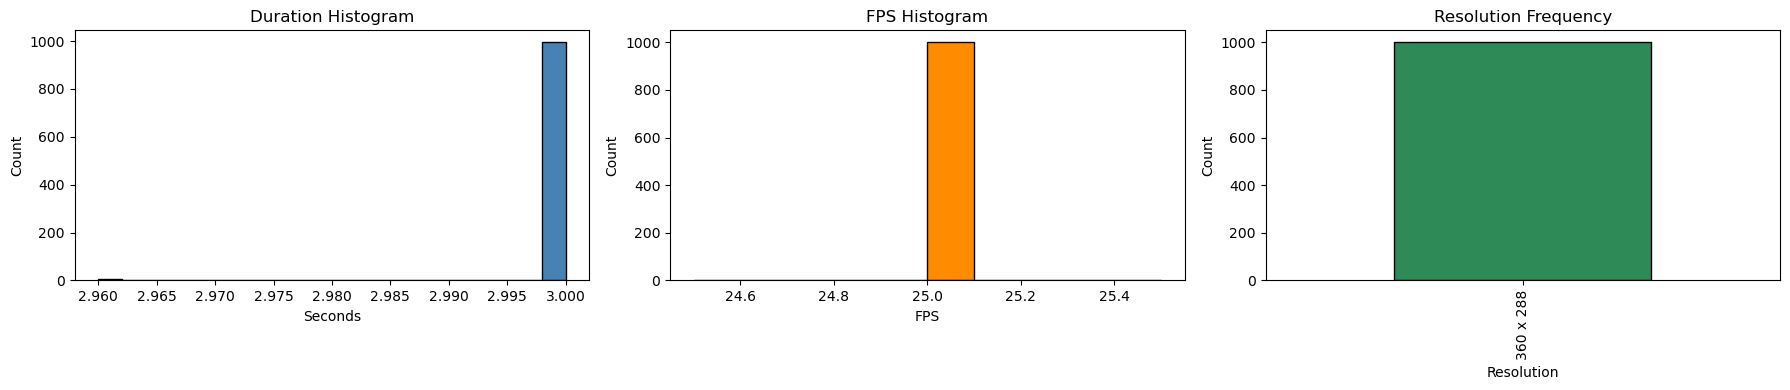

In [8]:
valid_videos = video_metadata_df[video_metadata_df['Readable'] == True].copy()

total_videos = len(valid_videos)
total_duration = valid_videos['Duration'].sum()
average_duration = valid_videos['Duration'].mean()
minimum_duration = valid_videos['Duration'].min()
maximum_duration = valid_videos['Duration'].max()
average_fps = valid_videos['FPS'].mean()
resolution_distribution = valid_videos['Resolution'].value_counts()
frame_count_distribution = valid_videos['Frame Count'].value_counts().sort_index()

print(f'Total videos: {total_videos}')
print(f'Total duration: {total_duration:.3f}')
print(f'Average duration: {average_duration:.6f}')
print(f'Minimum duration: {minimum_duration:.6f}')
print(f'Maximum duration: {maximum_duration:.6f}')
print(f'Average FPS: {average_fps:.3f}')
print('Resolution distribution:')
print(resolution_distribution)
print('Frame count distribution:')
print(frame_count_distribution)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(valid_videos['Duration'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Duration Histogram')
axes[0].set_xlabel('Seconds')
axes[0].set_ylabel('Count')

axes[1].hist(valid_videos['FPS'].dropna(), bins=10, color='darkorange', edgecolor='black')
axes[1].set_title('FPS Histogram')
axes[1].set_xlabel('FPS')
axes[1].set_ylabel('Count')

resolution_distribution.plot(kind='bar', ax=axes[2], color='seagreen', edgecolor='black')
axes[2].set_title('Resolution Frequency')
axes[2].set_xlabel('Resolution')
axes[2].set_ylabel('Count')
plt.tight_layout()
plt.show()

## 7. Final Audit Report

This section builds a Markdown report that summarizes the dataset audit results and writes it to `dataset_audit_report.md`.

In [9]:
def build_directory_summary(root: Path, files):
    lines = []
    directory_counts = Counter(str(path.parent.relative_to(root)) if path.parent != root else '.' for path in files)
    for folder, count in sorted(directory_counts.items()):
        lines.append(f'- {folder}: {count} file(s)')
    return ' '.join(lines)

def build_audit_report():
    label_text = 'NO VERIFIED LABEL SOURCE FOUND' if not label_sources else 'Verified label sources were found in the inspected metadata files.'
    speaker_text = 'NO VERIFIED SPEAKER INFORMATION FOUND' if not verified_speakers else 'Verified speaker information was found.'

    report = f'''# Dataset Audit Report

## Dataset Overview
- Dataset root: `{DATASET_ROOT}`
- Total files: {len(all_files)}
- Total video files: {len(video_files)}
- File type distribution: {dict(file_extensions)}

## Directory Structure
{build_directory_summary(DATASET_ROOT, all_files)}

## Video Statistics
- Total duration: {total_duration:.3f} seconds
- Average duration: {average_duration:.6f} seconds
- Minimum duration: {minimum_duration:.6f} seconds
- Maximum duration: {maximum_duration:.6f} seconds
- Average FPS: {average_fps:.3f}
- Resolution distribution: {dict(resolution_distribution)}
- Frame count distribution: {dict(frame_count_distribution)}

## Label Analysis
- {label_text}

## Speaker Analysis
- {speaker_text}

## Quality Assessment
- Unreadable or corrupted videos: {int((~video_metadata_df['Readable']).sum())}
- Empty files: {int((video_metadata_df['File Size'] == 0).sum())}
- Duplicate groups: {len(duplicate_groups)}
- Resolution variants: {len(resolution_distribution)}
- FPS variants: {valid_videos['FPS'].nunique()}

## Risks And Missing Information
- No verified label source was found if the metadata files do not explicitly map labels to videos.
- No verified speaker information was found if the dataset does not expose speaker IDs or a speaker manifest.
- Any filename pattern observations are recorded only as observations, not as labels or speakers.

## Final Summary
- Total videos inspected: {total_videos}
- Total duration: {total_duration:.3f} seconds
- Average duration: {average_duration:.6f} seconds
- Average FPS: {average_fps:.3f}
- The notebook completed dataset auditing only and did not perform preprocessing or model development.
'''
    return report

audit_report_md = build_audit_report()
(OUTPUT_DIR / 'dataset_audit_report.md').write_text(audit_report_md, encoding='utf-8')
print(audit_report_md)

# Dataset Audit Report

## Dataset Overview
- Dataset root: `C:\Users\prash\Downloads\archive (3)\data\s1`
- Total files: 1001
- Total video files: 1000
- File type distribution: {'.mpg': 1000, '.db': 1}

## Directory Structure
- .: 1001 file(s)

## Video Statistics
- Total duration: 2999.800 seconds
- Average duration: 2.999800 seconds
- Minimum duration: 2.960000 seconds
- Maximum duration: 3.000000 seconds
- Average FPS: 25.000
- Resolution distribution: {'360 x 288': np.int64(1000)}
- Frame count distribution: {74: np.int64(5), 75: np.int64(995)}

## Label Analysis
- NO VERIFIED LABEL SOURCE FOUND

## Speaker Analysis
- NO VERIFIED SPEAKER INFORMATION FOUND

## Quality Assessment
- Unreadable or corrupted videos: 0
- Empty files: 0
- Duplicate groups: 0
- Resolution variants: 1
- FPS variants: 1

## Risks And Missing Information
- No verified label source was found if the metadata files do not explicitly map labels to videos.
- No verified speaker information was found if the datas

## 7.5. Transcript Analysis

This section records `.align`-based transcript statistics and appends them to the final audit report.

In [26]:
def append_transcript_section(report_text: str):
    transcript_lines = [
        '',
        '## Transcript Analysis',
        f'- Number of align files found: {len(align_files)}',
        f'- Number of successful video-align pairs: {len(paired_stems)}',
        f'- Missing pairs: {len(missing_video_for_align) + len(missing_align_for_video)}',
        f'- Average transcript length: {average_words_per_transcript:.3f}',
        f'- Vocabulary size: {vocabulary_size}',
        '',
        '### Top 20 Most Frequent Words',
    ]

    if not vocabulary_df.empty:
        top_words = vocabulary_df.head(20)
        for _, row in top_words.iterrows():
            transcript_lines.append(f"- {row['Word']}: {int(row['Frequency'])}")
    else:
        transcript_lines.append('- No vocabulary could be derived from align files.')

    updated_report = report_text.rstrip() + '\n' + '\n'.join(transcript_lines) + '\n'
    (OUTPUT_DIR / 'dataset_audit_report.md').write_text(updated_report, encoding='utf-8')
    return updated_report

updated_audit_report_md = append_transcript_section(audit_report_md)
print(updated_audit_report_md)

# Dataset Audit Report

## Dataset Overview
- Dataset root: `C:\Users\prash\Downloads\archive (3)\data\s1`
- Total files: 1001
- Total video files: 1000
- File type distribution: {'.mpg': 1000, '.db': 1}

## Directory Structure
- .: 1001 file(s)

## Video Statistics
- Total duration: 2999.800 seconds
- Average duration: 2.999800 seconds
- Minimum duration: 2.960000 seconds
- Maximum duration: 3.000000 seconds
- Average FPS: 25.000
- Resolution distribution: {'360 x 288': np.int64(1000)}
- Frame count distribution: {74: np.int64(5), 75: np.int64(995)}

## Label Analysis
- NO VERIFIED LABEL SOURCE FOUND

## Speaker Analysis
- NO VERIFIED SPEAKER INFORMATION FOUND

## Quality Assessment
- Unreadable or corrupted videos: 0
- Empty files: 0
- Duplicate groups: 0
- Resolution variants: 1
- FPS variants: 1

## Risks And Missing Information
- No verified label source was found if the metadata files do not explicitly map labels to videos.
- No verified speaker information was found if the datas